In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import roc_auc_score, classification_report
from sklearn.pipeline        import Pipeline
from lifetimes                import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils          import summary_data_from_transaction_data

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.rcParams.update({
    'figure.facecolor' : '#ffffff',
    'axes.facecolor'   : '#f8f9fa',
    'axes.edgecolor'   : '#dee2e6',
    'axes.labelcolor'  : '#495057',
    'text.color'       : '#212529',
    'xtick.color'      : '#6c757d',
    'ytick.color'      : '#6c757d',
    'grid.color'       : '#e9ecef',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.7,
    'font.family'      : 'sans-serif',
    'axes.titlesize'   : 13,
    'axes.titleweight' : 'bold',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
events = pd.read_csv('../data/events.csv',
                     parse_dates=['event_timestamp'])
orders = pd.read_csv('../data/orders.csv',
                     parse_dates=['order_created_at'])
churn  = pd.read_csv('../data/churn_scores.csv')

OBS_START  = pd.Timestamp('2023-04-01')
OBS_CUTOFF = pd.Timestamp('2023-10-01')
EXP_START  = pd.Timestamp('2024-01-08')

pre_orders = orders[orders['order_created_at'] < OBS_CUTOFF].copy()
pre_events = events[events['event_timestamp']  < OBS_CUTOFF].copy()

print(f"Pre-experiment orders: {len(pre_orders):,}")
print(f"Pre-experiment events: {len(pre_events):,}")
print(f"Churn scores:          {len(churn):,}")
print(f"\nObservation window: {OBS_START.date()} → {OBS_CUTOFF.date()}")
print(f"Unique purchasers:  {pre_orders['user_pseudo_id'].nunique():,}")
display(pre_orders.head(3))

Pre-experiment orders: 1,007
Pre-experiment events: 46,717
Churn scores:          10,191

Observation window: 2023-04-01 → 2023-10-01
Unique purchasers:  915


,order_id,user_pseudo_id,session_id,order_created_at,item_id,item_name,product_category,price_tier,quantity,item_price,order_revenue,payment_method,is_returned,intent_level,dropoff_reason
0,ord_cb5a24,uid_bddc0f77,sess_uid_bddc0f77_20230922014800,2023-09-22 01:52:29,LUM-BW-01,Moisture Surge Body Wash 16oz,Body Wash,low,2,21.9900,43.9800,credit_card,False,very_high,converted
1,ord_118073,uid_48dc3539,sess_uid_48dc3539_20230724215900,2023-07-24 22:02:40,LUM-BW-01,Moisture Surge Body Wash 16oz,Body Wash,low,1,21.9900,43.9800,credit_card,False,very_high,converted
2,ord_4a31fe,uid_8b812441,sess_uid_8b812441_20230603203300,2023-06-03 20:37:54,LUM-BDL-01,Shampoo + Conditioner Duo,Bundle,mid,1,42.9900,85.9800,credit_card,True,very_high,converted


In [3]:
print("=" * 58)
print("SECTION 1 — RFM SEGMENTATION")
print("=" * 58)

# Compute R, F, M per user
rfm = (
    pre_orders.groupby('user_pseudo_id')
    .agg(
        last_purchase  = ('order_created_at', 'max'),
        first_purchase = ('order_created_at', 'min'),
        frequency      = ('order_id',         'nunique'),
        monetary       = ('order_revenue',     'sum'),
    )
    .reset_index()
)
rfm['recency_days'] = (OBS_CUTOFF - rfm['last_purchase']).dt.days

# All users from events (include non-purchasers)
all_users = pd.DataFrame({
    'user_pseudo_id': pre_events['user_pseudo_id'].unique()
})
rfm = all_users.merge(rfm, on='user_pseudo_id', how='left')
rfm['frequency']    = rfm['frequency'].fillna(0).astype(int)
rfm['monetary']     = rfm['monetary'].fillna(0)
rfm['recency_days'] = rfm['recency_days'].fillna(999)

# Add scroll depth and intent from events
scroll_intent = (
    pre_events.groupby('user_pseudo_id')
    .agg(
        avg_scroll     = ('scroll_depth',  'mean'),
        intent_mode    = ('intent_level',  lambda x: x.mode()[0]),
        dropoff_mode   = ('dropoff_reason',lambda x: x.mode()[0]),
    )
    .reset_index()
)
rfm = rfm.merge(scroll_intent, on='user_pseudo_id', how='left')

print(f"Users in RFM table:      {len(rfm):,}")
print(f"Users with purchases:    {(rfm['frequency']>0).sum():,}")
print(f"Users without purchases: {(rfm['frequency']==0).sum():,}")
display(rfm.head(3))

SECTION 1 — RFM SEGMENTATION
Users in RFM table:      10,191
Users with purchases:    915
Users without purchases: 9,276


,user_pseudo_id,last_purchase,first_purchase,frequency,monetary,recency_days,avg_scroll,intent_mode,dropoff_mode
0,uid_3791eb90,NaT,NaT,0,0.0000,999.0000,0.5570,very_high,converted
1,uid_440a6a81,NaT,NaT,0,0.0000,999.0000,0.5900,low,impulse_faded
2,uid_e23fd893,NaT,NaT,0,0.0000,999.0000,0.4417,low,impulse_faded


In [4]:
def rfm_score(series, ascending=True, n=4):
    """Score series into n quartile buckets."""
    try:
        if ascending:
            labels = list(range(n, 0, -1))
        else:
            labels = list(range(1, n+1))
        scored = pd.qcut(series, n, labels=labels,
                         duplicates='drop')
    except Exception:
        scored = pd.Series(1, index=series.index)
    return scored.astype(float).fillna(1).astype(int)

purchasers_mask = rfm['frequency'] > 0

rfm['R_score'] = 1
rfm['F_score'] = 1
rfm['M_score'] = 1

if purchasers_mask.sum() > 0:
    rfm.loc[purchasers_mask, 'R_score'] = rfm_score(
        rfm.loc[purchasers_mask, 'recency_days'],
        ascending=True
    )
    rfm.loc[purchasers_mask, 'F_score'] = rfm_score(
        rfm.loc[purchasers_mask, 'frequency'],
        ascending=False
    )
    rfm.loc[purchasers_mask, 'M_score'] = rfm_score(
        rfm.loc[purchasers_mask, 'monetary'],
        ascending=False
    )

rfm['RFM_score']    = (rfm['R_score'].astype(str) + '-' +
                       rfm['F_score'].astype(str) + '-' +
                       rfm['M_score'].astype(str))
rfm['RFM_combined'] = (rfm['R_score']*100 +
                       rfm['F_score']*10  +
                       rfm['M_score'])

print("RFM score distribution (purchasers only):")
print(rfm[purchasers_mask][['R_score','F_score','M_score']]
      .describe().round(2).to_string())

RFM score distribution (purchasers only):
       R_score  F_score  M_score
count 915.0000 915.0000 915.0000
mean    2.5000   1.0000   2.4300
std     1.1200   0.0000   1.1400
min     1.0000   1.0000   1.0000
25%     1.5000   1.0000   1.0000
50%     3.0000   1.0000   2.0000
75%     4.0000   1.0000   3.0000
max     4.0000   1.0000   4.0000


In [5]:
def assign_rfm_segment(row):
    r    = row['R_score']
    f    = row['F_score']
    m    = row['M_score']
    freq = row['frequency']

    if freq == 0:
        return 'Lost / Non-Buyer'
    elif r >= 4 and f >= 4 and m >= 4:
        return 'Champion'
    elif r >= 3 and f >= 3:
        return 'Loyal Customer'
    elif r >= 4 and f <= 2:
        return 'New Customer'
    elif r >= 3 and f <= 2:
        return 'Potential Loyalist'
    elif r == 2 and f >= 2:
        return 'At Risk'
    elif r == 1 and f >= 3:
        return 'Cannot Lose Them'
    elif r <= 2 and f <= 2 and m >= 3:
        return 'Hibernating (High Value)'
    else:
        return 'Hibernating'

rfm['segment'] = rfm.apply(assign_rfm_segment, axis=1)

seg_summary = (
    rfm.groupby('segment')
    .agg(
        users         = ('user_pseudo_id',  'count'),
        avg_recency   = ('recency_days',
            lambda x: x[x<999].mean()),
        avg_frequency = ('frequency',       'mean'),
        avg_monetary  = ('monetary',        'mean'),
        total_revenue = ('monetary',        'sum'),
        avg_scroll    = ('avg_scroll',      'mean'),
    )
    .reset_index()
    .sort_values('total_revenue', ascending=False)
)

print("RFM Segments:")
display(seg_summary.round(2))

RFM Segments:


,segment,users,avg_recency,avg_frequency,avg_monetary,total_revenue,avg_scroll
1,Hibernating (High Value),231,117.0700,1.1500,66.0300,15253.8200,0.5200
3,New Customer,232,16.4600,1.1400,48.0800,11154.2500,0.5200
4,Potential Loyalist,226,51.5400,1.1100,49.1300,11104.3000,0.5000
0,Hibernating,226,121.9100,1.0000,32.2200,7281.4500,0.5000
2,Lost / Non-Buyer,9276,NaN,0.0000,0.0000,0.0000,0.4100


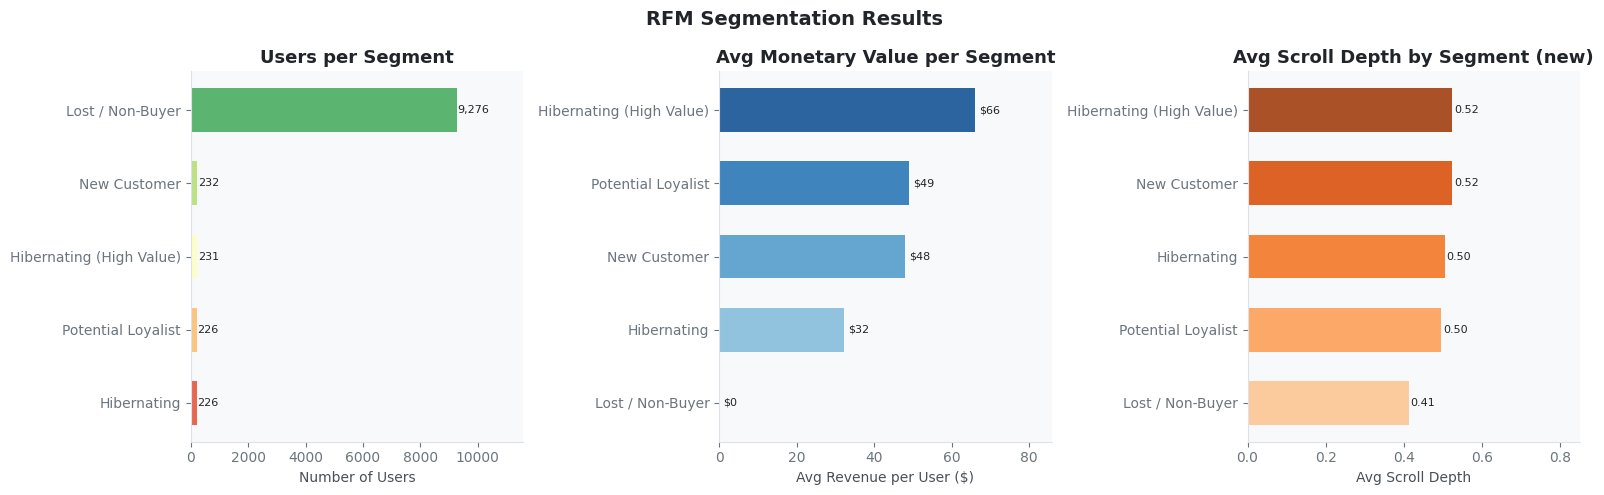


Top 3 segments by total revenue:
  Hibernating (High Value)       $  15,254  (231 users)
  New Customer                   $  11,154  (232 users)
  Potential Loyalist             $  11,104  (226 users)


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('RFM Segmentation Results', fontsize=14, fontweight='bold')

n_segs = len(seg_summary)
colors = plt.cm.RdYlGn(np.linspace(0.15, 0.85, n_segs))

# Users per segment
ax = axes[0]
sp = seg_summary.sort_values('users', ascending=True)
bars = ax.barh(sp['segment'], sp['users'],
               color=colors, height=0.6, alpha=0.85)
ax.set_xlabel('Number of Users')
ax.set_title('Users per Segment')
for bar, val in zip(bars, sp['users']):
    ax.text(bar.get_width()+10,
            bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
ax.set_xlim(0, sp['users'].max()*1.25)

# Avg monetary
ax2 = axes[1]
sm = seg_summary.sort_values('avg_monetary', ascending=True)
colors2 = plt.cm.Blues(np.linspace(0.3, 0.9, n_segs))
bars2 = ax2.barh(sm['segment'], sm['avg_monetary'],
                 color=colors2, height=0.6, alpha=0.85)
ax2.set_xlabel('Avg Revenue per User ($)')
ax2.set_title('Avg Monetary Value per Segment')
for bar, val in zip(bars2, sm['avg_monetary']):
    ax2.text(bar.get_width()+1,
             bar.get_y()+bar.get_height()/2,
             f'${val:.0f}', va='center', fontsize=8)
ax2.set_xlim(0, sm['avg_monetary'].max()*1.3)

# Avg scroll depth by segment (new)
ax3 = axes[2]
ss = seg_summary.sort_values('avg_scroll', ascending=True)
colors3 = plt.cm.Oranges(np.linspace(0.3, 0.9, n_segs))
bars3 = ax3.barh(ss['segment'], ss['avg_scroll'],
                 color=colors3, height=0.6, alpha=0.85)
ax3.set_xlabel('Avg Scroll Depth')
ax3.set_title('Avg Scroll Depth by Segment (new)')
for bar, val in zip(bars3, ss['avg_scroll']):
    if pd.notna(val):
        ax3.text(bar.get_width()+0.005,
                 bar.get_y()+bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=8)
ax3.set_xlim(0, 0.85)

plt.tight_layout()
plt.savefig('../data/rfm_segments.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 3 segments by total revenue:")
for _, row in seg_summary.head(3).iterrows():
    print(f"  {row['segment']:<30} ${row['total_revenue']:>8,.0f}  "
          f"({row['users']:,} users)")

In [7]:
print("=" * 58)
print("SECTION 2 — CLV PREDICTION")
print("=" * 58)
print("""
BG/NBD estimates expected future purchases.
Gamma-Gamma estimates expected future AOV.
CLV = predicted purchases × predicted AOV × margin.
""")

bgf_data = summary_data_from_transaction_data(
    pre_orders,
    customer_id_col        = 'user_pseudo_id',
    datetime_col           = 'order_created_at',
    observation_period_end = OBS_CUTOFF,
    freq                   = 'D',
)

print(f"Users in BG/NBD:        {len(bgf_data):,}")
print(f"Repeat purchasers:      {(bgf_data['frequency']>0).sum():,}")
print(f"\nBG/NBD input summary:")
display(bgf_data.describe().round(2))

SECTION 2 — CLV PREDICTION

BG/NBD estimates expected future purchases.
Gamma-Gamma estimates expected future AOV.
CLV = predicted purchases × predicted AOV × margin.

Users in BG/NBD:        915
Repeat purchasers:      84

BG/NBD input summary:


,frequency,recency,T
count,915.0000,915.0000,915.0000
mean,0.1000,3.6000,81.1700
std,0.3300,13.2300,50.0400
min,0.0000,0.0000,1.0000
25%,0.0000,0.0000,38.0000
50%,0.0000,0.0000,80.0000
75%,0.0000,0.0000,122.0000
max,3.0000,135.0000,183.0000


In [8]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(
    bgf_data['frequency'],
    bgf_data['recency'],
    bgf_data['T'],
)

print("BG/NBD fitted ✓")
print(f"\nModel parameters:")
print(bgf.summary.round(4).to_string())

bgf_data['predicted_purchases_90d'] = \
    bgf.conditional_expected_number_of_purchases_up_to_time(
        90,
        bgf_data['frequency'],
        bgf_data['recency'],
        bgf_data['T'],
    )
bgf_data['p_alive'] = bgf.conditional_probability_alive(
    bgf_data['frequency'],
    bgf_data['recency'],
    bgf_data['T'],
)

print(f"\nPredicted purchases (next 90 days):")
print(f"  Mean:   {bgf_data['predicted_purchases_90d'].mean():.2f}")
print(f"  Median: {bgf_data['predicted_purchases_90d'].median():.2f}")
print(f"\nP(alive):")
print(f"  Mean:   {bgf_data['p_alive'].mean():.2f}")
print(f"  Users likely alive (>0.5): "
      f"{(bgf_data['p_alive']>0.5).sum():,}")

BG/NBD fitted ✓

Model parameters:
         coef  se(coef)  lower 95% bound  upper 95% bound
r      0.1240    0.0290           0.0672           0.1807
alpha 60.4082   19.0522          23.0658          97.7506
a      0.1625    0.1840          -0.1982           0.5232
b      0.0409    0.0487          -0.0546           0.1364

Predicted purchases (next 90 days):
  Mean:   0.08
  Median: 0.07

P(alive):
  Mean:   0.93
  Users likely alive (>0.5): 838


In [9]:
gg_data = bgf_data[bgf_data['frequency']>0].copy()

avg_aov = (
    pre_orders.groupby('user_pseudo_id')['order_revenue']
    .mean().reset_index()
    .rename(columns={'order_revenue':'avg_order_value'})
)
gg_data = gg_data.merge(avg_aov, on='user_pseudo_id', how='left')
gg_data = gg_data[gg_data['avg_order_value']>0].copy()

print(f"Users for Gamma-Gamma: {len(gg_data):,}")

ggf = GammaGammaFitter(penalizer_coef=0.001)
ggf.fit(gg_data['frequency'], gg_data['avg_order_value'])

print("Gamma-Gamma fitted ✓")
print(f"\nModel parameters:")
print(ggf.summary.round(4).to_string())

gg_data['predicted_aov'] = ggf.conditional_expected_average_profit(
    gg_data['frequency'],
    gg_data['avg_order_value'],
)

print(f"\nActual mean AOV:    ${gg_data['avg_order_value'].mean():.2f}")
print(f"Predicted mean AOV: ${gg_data['predicted_aov'].mean():.2f}")

Users for Gamma-Gamma: 84
Gamma-Gamma fitted ✓

Model parameters:
     coef  se(coef)  lower 95% bound  upper 95% bound
p 12.5982    1.5401           9.5795          15.6169
q  3.8279    0.5852           2.6810           4.9749
v 10.9166    1.5005           7.9756          13.8577

Actual mean AOV:    $42.53
Predicted mean AOV: $43.65


In [10]:
MARGIN        = 0.65
MONTHS        = 6
DISCOUNT_RATE = 0.01

clv_values = ggf.customer_lifetime_value(
    bgf,
    gg_data['frequency'],
    gg_data['recency'],
    gg_data['T'],
    gg_data['avg_order_value'],
    time          = MONTHS,
    discount_rate = DISCOUNT_RATE,
    freq          = 'D',
)
gg_data['clv_6month'] = clv_values.values

# Single-purchase users (freq=0 in BG/NBD)
single_buyers = bgf_data[bgf_data['frequency']==0].copy()
single_buyers = single_buyers.merge(avg_aov, on='user_pseudo_id', how='left')
single_buyers['avg_order_value'] = single_buyers['avg_order_value'].fillna(0)
single_buyers['clv_6month'] = (
    single_buyers['predicted_purchases_90d'] * 2 *
    single_buyers['avg_order_value'] * MARGIN
)

# Non-purchasers
non_buyers = pd.DataFrame({
    'user_pseudo_id': rfm[rfm['frequency']==0]['user_pseudo_id'],
    'clv_6month'    : 0.0,
})

# Combine
clv_all = pd.concat([
    gg_data[['user_pseudo_id','clv_6month','predicted_aov','p_alive']],
    single_buyers[['user_pseudo_id','clv_6month']],
    non_buyers[['user_pseudo_id','clv_6month']],
], ignore_index=True).drop_duplicates('user_pseudo_id')

print(f"CLV computed for {len(clv_all):,} users")
print(f"\nCLV distribution:")
print(clv_all['clv_6month'].describe().round(2).to_string())
print(f"\nTotal predicted 6-month revenue: "
      f"${clv_all['clv_6month'].sum():,.0f}")

CLV computed for 10,191 users

CLV distribution:
count   10191.0000
mean        0.4400
std         2.5900
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
max       119.0500

Total predicted 6-month revenue: $4,444


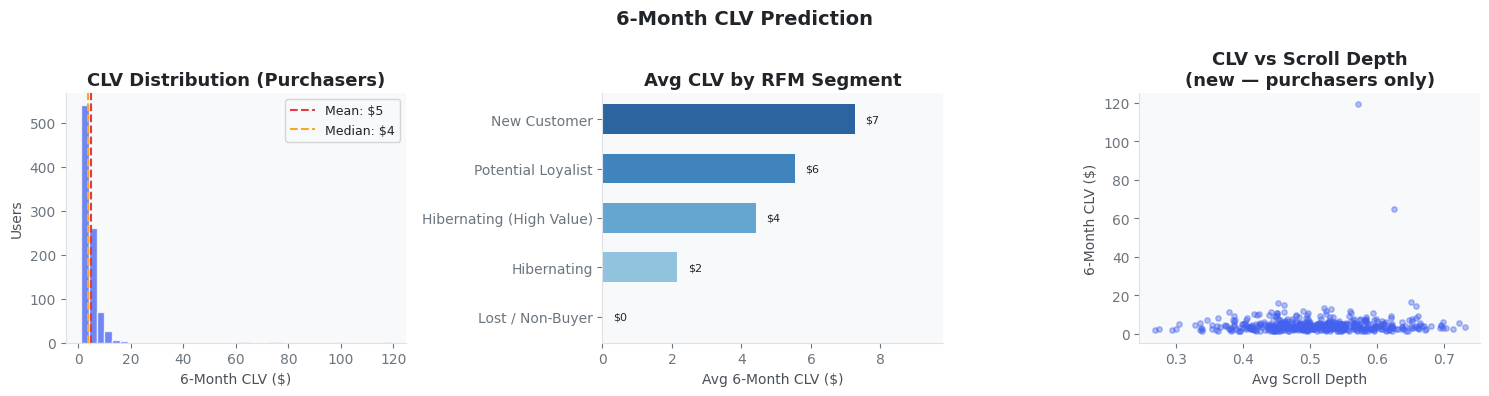


Total predicted 6-month revenue: $4,444
Avg CLV per purchaser:           $4.86
Max CLV:                         $119.05


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('6-Month CLV Prediction', fontsize=14, fontweight='bold')

clv_purchasers = clv_all[clv_all['clv_6month']>0]['clv_6month']

# Distribution
ax = axes[0]
ax.hist(clv_purchasers, bins=40,
        color='#4361ee', alpha=0.75, edgecolor='white')
ax.axvline(clv_purchasers.mean(), color='#e63946',
           linestyle='--', linewidth=1.5,
           label=f"Mean: ${clv_purchasers.mean():.0f}")
ax.axvline(clv_purchasers.median(), color='#f9a825',
           linestyle='--', linewidth=1.5,
           label=f"Median: ${clv_purchasers.median():.0f}")
ax.set_xlabel('6-Month CLV ($)')
ax.set_ylabel('Users')
ax.set_title('CLV Distribution (Purchasers)')
ax.legend(fontsize=9)

# CLV by RFM segment
ax2 = axes[1]
clv_rfm = clv_all.merge(
    rfm[['user_pseudo_id','segment']], on='user_pseudo_id', how='left')
seg_clv = (
    clv_rfm.groupby('segment')['clv_6month']
    .mean().reset_index()
    .sort_values('clv_6month', ascending=True)
)
colors2 = plt.cm.Blues(np.linspace(0.3, 0.9, len(seg_clv)))
bars = ax2.barh(seg_clv['segment'], seg_clv['clv_6month'],
                color=colors2, height=0.6, alpha=0.85)
ax2.set_xlabel('Avg 6-Month CLV ($)')
ax2.set_title('Avg CLV by RFM Segment')
for bar, val in zip(bars, seg_clv['clv_6month']):
    ax2.text(bar.get_width()+0.3,
             bar.get_y()+bar.get_height()/2,
             f'${val:.0f}', va='center', fontsize=8)
ax2.set_xlim(0, seg_clv['clv_6month'].max()*1.35)

# CLV vs scroll depth scatter
ax3 = axes[2]
clv_scroll = clv_all.merge(
    rfm[['user_pseudo_id','avg_scroll']], on='user_pseudo_id', how='left')
clv_scroll = clv_scroll[clv_scroll['clv_6month']>0].sample(
    min(500, len(clv_scroll)), random_state=42)
ax3.scatter(clv_scroll['avg_scroll'],
            clv_scroll['clv_6month'],
            alpha=0.40, color='#4361ee', s=15)
ax3.set_xlabel('Avg Scroll Depth')
ax3.set_ylabel('6-Month CLV ($)')
ax3.set_title('CLV vs Scroll Depth\n(new — purchasers only)')

plt.tight_layout()
plt.savefig('../data/clv_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal predicted 6-month revenue: "
      f"${clv_all['clv_6month'].sum():,.0f}")
print(f"Avg CLV per purchaser:           "
      f"${clv_purchasers.mean():.2f}")
print(f"Max CLV:                         "
      f"${clv_all['clv_6month'].max():.2f}")

In [12]:
print("=" * 58)
print("SECTION 3 — PROPENSITY TO PURCHASE (30-DAY)")
print("=" * 58)
print("""
Label: did user purchase in Sep 2023?
Features: behavior Apr–Sep 1, 2023
New features: scroll depth + intent level score
""")

PROP_OBS_END   = pd.Timestamp('2023-09-01')
PROP_LABEL_END = pd.Timestamp('2023-10-01')

prop_events = events[
    (events['event_timestamp'] >= OBS_START) &
    (events['event_timestamp'] <  PROP_OBS_END)
].copy()
prop_orders = orders[
    (orders['order_created_at'] >= OBS_START) &
    (orders['order_created_at'] <  PROP_OBS_END)
].copy()

# Session features
prop_feats = (
    prop_events.groupby('user_pseudo_id')
    .agg(
        total_sessions      = ('session_id',        'nunique'),
        total_pdp_views     = ('event_name',
            lambda x: (x=='view_item').sum()),
        total_plp_views     = ('event_name',
            lambda x: (x=='view_item_list').sum()),
        total_atc           = ('event_name',
            lambda x: (x=='add_to_cart').sum()),
        last_visit          = ('event_timestamp',   'max'),
        favorite_device     = ('device_category',
            lambda x: x.mode()[0]),
        favorite_source     = ('traffic_source',
            lambda x: x.mode()[0]),
        favorite_tier       = ('price_tier',
            lambda x: x.mode()[0]),
        avg_scroll_depth    = ('scroll_depth',      'mean'),
        intent_level_mode   = ('intent_level',
            lambda x: x.mode()[0]),
        dropoff_reason_mode = ('dropoff_reason',
            lambda x: x.mode()[0]),
    )
    .reset_index()
)

prop_feats['days_since_last_visit'] = (
    PROP_OBS_END - prop_feats['last_visit']
).dt.days
prop_feats['pdp_per_session'] = (
    prop_feats['total_pdp_views'] /
    prop_feats['total_sessions'].clip(lower=1)
)
prop_feats['atc_per_session'] = (
    prop_feats['total_atc'] /
    prop_feats['total_sessions'].clip(lower=1)
)

# Intent and drop-off encoding
intent_score_map = {
    'very_low':1,'low':2,'medium':3,'high':4,'very_high':5
}
reason_score_map = {
    'converted':5,'decision_friction':4,'comparison_intent':4,
    'price_barrier':3,'out_of_stock':3,'distraction':2,
    'price_shock':2,'impulse_faded':1,'ad_pdp_mismatch':1,
    'wrong_audience':0,
}
prop_feats['intent_score']  = prop_feats['intent_level_mode'].map(
    intent_score_map).fillna(3)
prop_feats['dropoff_score'] = prop_feats['dropoff_reason_mode'].map(
    reason_score_map).fillna(2)

# Order features
prop_order_feats = (
    prop_orders.groupby('user_pseudo_id')
    .agg(
        total_orders    = ('order_id',      'nunique'),
        total_revenue   = ('order_revenue', 'sum'),
        avg_order_value = ('order_revenue', 'mean'),
    )
    .reset_index()
)
prop_feats = prop_feats.merge(
    prop_order_feats, on='user_pseudo_id', how='left')
prop_feats[['total_orders','total_revenue','avg_order_value']] = \
    prop_feats[['total_orders','total_revenue','avg_order_value']].fillna(0)

# Labels
label_buyers = orders[
    (orders['order_created_at'] >= PROP_OBS_END) &
    (orders['order_created_at'] <  PROP_LABEL_END)
]['user_pseudo_id'].unique()
prop_feats['will_purchase'] = prop_feats['user_pseudo_id'].isin(
    label_buyers).astype(int)

print(f"Users: {len(prop_feats):,}")
print(f"Will purchase (label=1): {prop_feats['will_purchase'].sum():,} "
      f"({prop_feats['will_purchase'].mean():.1%})")

SECTION 3 — PROPENSITY TO PURCHASE (30-DAY)

Label: did user purchase in Sep 2023?
Features: behavior Apr–Sep 1, 2023
New features: scroll depth + intent level score

Users: 8,534
Will purchase (label=1): 110 (1.3%)


In [13]:
prop_encoded = pd.get_dummies(
    prop_feats,
    columns=['favorite_device','favorite_source','favorite_tier'],
    drop_first=False
)

drop_cols  = ['user_pseudo_id','last_visit','will_purchase',
              'intent_level_mode','dropoff_reason_mode']
feat_cols  = [c for c in prop_encoded.columns if c not in drop_cols]

X = prop_encoded[feat_cols].fillna(0)
y = prop_encoded['will_purchase']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

prop_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LogisticRegression(
        max_iter=1000, random_state=42,
        class_weight='balanced'
    ))
])
prop_model.fit(X_train, y_train)
prop_proba = prop_model.predict_proba(X_test)[:,1]
prop_auc   = roc_auc_score(y_test, prop_proba)

print(f"Propensity model AUC: {prop_auc:.4f}")
print(f"\nClassification Report:")
print(classification_report(
    y_test, prop_model.predict(X_test),
    target_names=['Will Not Buy','Will Buy']
))

# Check new feature coefficients
lr_coefs = pd.DataFrame({
    'feature'    : feat_cols,
    'coefficient': prop_model.named_steps['model'].coef_[0],
}).sort_values('coefficient', ascending=False)

print("\nNew feature coefficients in propensity model:")
for feat in ['avg_scroll_depth','intent_score','dropoff_score']:
    row = lr_coefs[lr_coefs['feature']==feat]
    if len(row):
        print(f"  {feat:<30} coef={row['coefficient'].values[0]:+.3f}")

Propensity model AUC: 0.7557

Classification Report:
              precision    recall  f1-score   support

Will Not Buy       0.99      0.71      0.83      1685
    Will Buy       0.03      0.59      0.05        22

    accuracy                           0.71      1707
   macro avg       0.51      0.65      0.44      1707
weighted avg       0.98      0.71      0.82      1707


New feature coefficients in propensity model:
  avg_scroll_depth               coef=-0.110
  intent_score                   coef=+0.029
  dropoff_score                  coef=-0.001


Propensity tier distribution:
propensity_tier
Low Propensity       4421
Medium Propensity    2227
High Propensity      1886


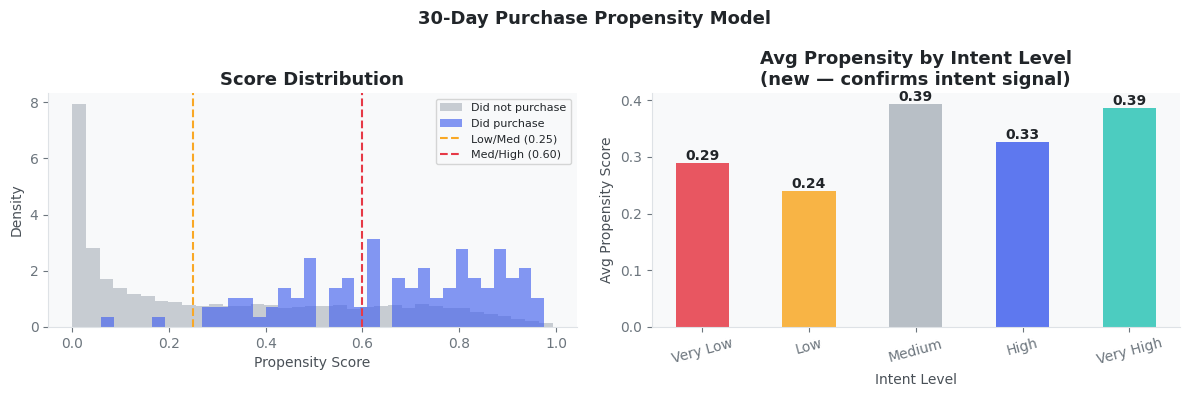


Model AUC: 0.7557
High propensity users: 1,886


In [14]:
prop_feats['propensity_score'] = prop_model.predict_proba(
    prop_encoded[feat_cols].fillna(0)
)[:,1]

prop_feats['propensity_tier'] = pd.cut(
    prop_feats['propensity_score'],
    bins   = [0, 0.25, 0.60, 1.0],
    labels = ['Low Propensity','Medium Propensity','High Propensity']
)

print("Propensity tier distribution:")
print(prop_feats['propensity_tier'].value_counts().to_string())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('30-Day Purchase Propensity Model',
             fontsize=13, fontweight='bold')

# Score distribution
ax = axes[0]
ax.hist(prop_feats[prop_feats['will_purchase']==0]['propensity_score'],
        bins=35, alpha=0.65, color='#adb5bd',
        label='Did not purchase', density=True)
ax.hist(prop_feats[prop_feats['will_purchase']==1]['propensity_score'],
        bins=35, alpha=0.65, color='#4361ee',
        label='Did purchase', density=True)
ax.axvline(0.25, color='#f9a825', linestyle='--',
           linewidth=1.5, label='Low/Med (0.25)')
ax.axvline(0.60, color='#e63946', linestyle='--',
           linewidth=1.5, label='Med/High (0.60)')
ax.set_xlabel('Propensity Score')
ax.set_ylabel('Density')
ax.set_title('Score Distribution')
ax.legend(fontsize=8)

# Avg propensity by intent level
ax2 = axes[1]
intent_order = ['very_low','low','medium','high','very_high']
intent_prop  = (
    prop_feats.groupby('intent_level_mode')['propensity_score']
    .mean().reindex(intent_order).fillna(0)
)
intent_colors = ['#e63946','#f9a825','#adb5bd','#4361ee','#2ec4b6']
bars = ax2.bar(
    [i.replace('_',' ').title() for i in intent_prop.index],
    intent_prop.values, color=intent_colors,
    width=0.5, alpha=0.85
)
ax2.set_xlabel('Intent Level')
ax2.set_ylabel('Avg Propensity Score')
ax2.set_title('Avg Propensity by Intent Level\n(new — confirms intent signal)')
ax2.tick_params(axis='x', labelrotation=15)
for bar, v in zip(bars, intent_prop.values):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.005,
             f'{v:.2f}', ha='center',
             fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../data/propensity_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f"\nModel AUC: {prop_auc:.4f}")
print(f"High propensity users: "
      f"{(prop_feats['propensity_tier']=='High Propensity').sum():,}")

In [15]:
print("Building retention master table...")

retention = prop_feats[[
    'user_pseudo_id','total_sessions','total_orders',
    'total_revenue','avg_order_value',
    'days_since_last_visit','avg_scroll_depth',
    'intent_score','propensity_score',
    'propensity_tier','will_purchase',
]].copy()

# Join RFM
retention = retention.merge(
    rfm[['user_pseudo_id','R_score','F_score','M_score',
         'recency_days','frequency','monetary',
         'segment','avg_scroll','intent_mode']],
    on='user_pseudo_id', how='left'
)

# Join CLV
retention = retention.merge(
    clv_all[['user_pseudo_id','clv_6month']],
    on='user_pseudo_id', how='left'
)
retention['clv_6month'] = retention['clv_6month'].fillna(0)

# Join churn score
retention = retention.merge(
    churn[['user_pseudo_id','xgb_churn_prob','churn_risk_tier']],
    on='user_pseudo_id', how='left'
)

# CLV tier
retention['clv_tier'] = pd.cut(
    retention['clv_6month'],
    bins   = [-1, 0, 50, 200, float('inf')],
    labels = ['No Value','Low Value','Medium Value','High Value']
)

retention.to_csv('../data/retention_master.csv', index=False)

print(f"Saved retention_master.csv")
print(f"  Rows:    {len(retention):,}")
print(f"  Columns: {retention.shape[1]}")
print(f"\nColumns: {retention.columns.tolist()}")

Building retention master table...
Saved retention_master.csv
  Rows:    8,534
  Columns: 24

Columns: ['user_pseudo_id', 'total_sessions', 'total_orders', 'total_revenue', 'avg_order_value', 'days_since_last_visit', 'avg_scroll_depth', 'intent_score', 'propensity_score', 'propensity_tier', 'will_purchase', 'R_score', 'F_score', 'M_score', 'recency_days', 'frequency', 'monetary', 'segment', 'avg_scroll', 'intent_mode', 'clv_6month', 'xgb_churn_prob', 'churn_risk_tier', 'clv_tier']


In [16]:
print("=" * 65)
print("RETENTION MODEL SUMMARY")
print("=" * 65)

clv_purchasers = clv_all[clv_all['clv_6month']>0]['clv_6month']
high_prop = (prop_feats['propensity_tier']=='High Propensity').sum()

print(f"""
SECTION 1 — RFM SEGMENTATION
  Total users segmented:   {len(rfm):,}
  Segments identified:     {rfm['segment'].nunique()}

  Top segments by revenue:
""")

for _, row in seg_summary.head(4).iterrows():
    print(f"    {row['segment']:<30} "
          f"${row['total_revenue']:>8,.0f}  "
          f"({row['users']:,} users)  "
          f"scroll={row['avg_scroll']:.2f}")

print(f"""
SECTION 2 — CLV PREDICTION (6-month)
  Users with CLV > 0:      {(clv_all['clv_6month']>0).sum():,}
  Total predicted revenue: ${clv_all['clv_6month'].sum():,.0f}
  Avg CLV (purchasers):    ${clv_purchasers.mean():.2f}
  Max CLV:                 ${clv_all['clv_6month'].max():.2f}

SECTION 3 — PROPENSITY TO PURCHASE (30-day)
  Model AUC:               {prop_auc:.4f}
  High propensity users:   {high_prop:,}
  Medium propensity:       {(prop_feats['propensity_tier']=='Medium Propensity').sum():,}
  Low propensity:          {(prop_feats['propensity_tier']=='Low Propensity').sum():,}

NEW FEATURES IMPACT
  avg_scroll_depth in propensity model: ✓
  intent_score in propensity model:     ✓
  dropoff_score in propensity model:    ✓

OUTPUT
  retention_master.csv — {len(retention):,} users, {retention.shape[1]} cols
""")

print("=" * 65)
print("→ All 8 notebooks complete")
print("→ Next: streamlit_app.py (full rebuild)")

RETENTION MODEL SUMMARY

SECTION 1 — RFM SEGMENTATION
  Total users segmented:   10,191
  Segments identified:     5

  Top segments by revenue:

    Hibernating (High Value)       $  15,254  (231 users)  scroll=0.52
    New Customer                   $  11,154  (232 users)  scroll=0.52
    Potential Loyalist             $  11,104  (226 users)  scroll=0.50
    Hibernating                    $   7,281  (226 users)  scroll=0.50

SECTION 2 — CLV PREDICTION (6-month)
  Users with CLV > 0:      915
  Total predicted revenue: $4,444
  Avg CLV (purchasers):    $4.86
  Max CLV:                 $119.05

SECTION 3 — PROPENSITY TO PURCHASE (30-day)
  Model AUC:               0.7557
  High propensity users:   1,886
  Medium propensity:       2,227
  Low propensity:          4,421

NEW FEATURES IMPACT
  avg_scroll_depth in propensity model: ✓
  intent_score in propensity model:     ✓
  dropoff_score in propensity model:    ✓

OUTPUT
  retention_master.csv — 8,534 users, 24 cols

→ All 8 notebooks c